In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Correct file path
file_path = "tesla_deliveries_dataset_2015_2025.csv"

# Load dataset
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "nalisha/tesla-ea-deliveries-and-production-data20152025",
    file_path
)

print("First 5 records:")
print(df.head())

/tmp/ipykernel_7581/4086724032.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 220k/220k [00:00<00:00, 1.05MB/s]

First 5 records:
   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from statsmodels.tsa.stattools import adfuller

In [3]:
df.shape

(2640, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [5]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [6]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [7]:
df.drop_duplicates(inplace=True)

In [8]:
print("\nRANDOM SAMPLE")
print(df.sample(5))


RANDOM SAMPLE
      Year  Month         Region    Model  Estimated_Deliveries  \
1689  2018     10    Middle East  Model X                  6459   
2176  2025      6         Europe  Model X                  9221   
2404  2023     10  North America  Model 3                 11636   
2339  2025     11    Middle East  Model 3                  4645   
2633  2016     12         Europe  Model 3                  9327   

      Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
1689              7254       88124.16                   120       664   
2176             10089      108823.54                   120       668   
2404             12345       61678.68                   120       661   
2339              4827       65577.08                    82       480   
2633              9705      117649.22                   120       693   

      CO2_Saved_tons           Source_Type  Charging_Stations  
1689          643.32  Interpolated (Month)              14465  
2176          9

In [9]:
print("\nDATASET SHAPE")
print(df.shape)


DATASET SHAPE
(2640, 12)


In [10]:
print("\nCOLUMN NAMES")
print(df.columns)


COLUMN NAMES
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')


In [11]:
print("\nDATASET INFO")
print(df.info())


DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None


In [12]:
print("\nSTATISTICAL SUMMARY")
print(df.describe())


STATISTICAL SUMMARY
              Year        Month  Estimated_Deliveries  Production_Units  \
count  2640.000000  2640.000000           2640.000000       2640.000000   
mean   2020.000000     6.500000           9922.199621      10655.847348   
std       3.162877     3.452707           3935.950093       4260.600858   
min    2015.000000     1.000000             48.000000         50.000000   
25%    2017.000000     3.750000           7292.000000       7828.250000   
50%    2020.000000     6.500000           9857.000000      10546.500000   
75%    2023.000000     9.250000          12510.250000      13469.000000   
max    2025.000000    12.000000          25704.000000      28939.000000   

       Avg_Price_USD  Battery_Capacity_kWh     Range_km  CO2_Saved_tons  \
count    2640.000000           2640.000000  2640.000000     2640.000000   
mean    84907.340330             87.059470   500.257576      744.076989   
std     20123.258036             20.836265   120.868549      353.221224   
min

In [13]:
print("\nMISSING VALUES")
print(df.isnull().sum())


MISSING VALUES
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [14]:
print("\nDUPLICATE VALUES")
print(df.duplicated().sum())


DUPLICATE VALUES
0


In [15]:
print("\nUNIQUE REGIONS")
print(df['Region'].unique())


UNIQUE REGIONS
['Europe' 'Asia' 'North America' 'Middle East']


In [16]:
print("\nUNIQUE MODELS")
print(df['Model'].unique())


UNIQUE MODELS
['Model S' 'Model X' 'Model 3' 'Model Y' 'Cybertruck']


In [17]:
print("\nUNIQUE SOURCE TYPES")
print(df['Source_Type'].unique())


UNIQUE SOURCE TYPES
['Interpolated (Month)' 'Official (Quarter)' 'Estimated (Region)']


In [18]:
sns.set_style("darkgrid")    #for the asthetics

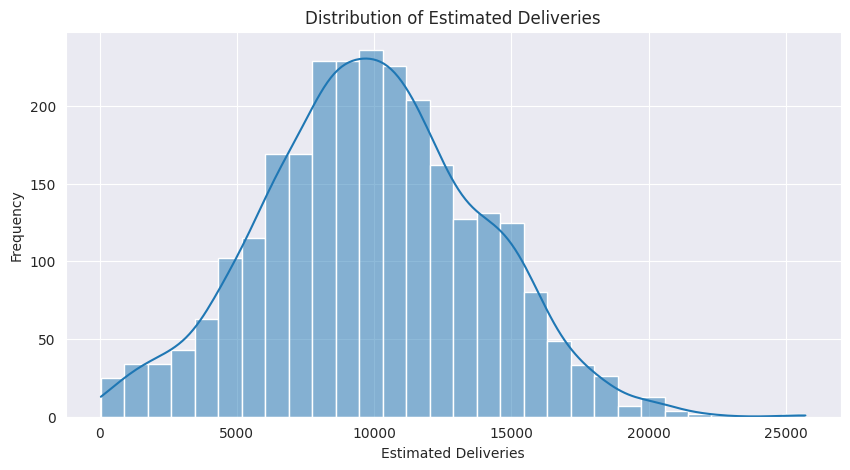

In [19]:
# Estimated Deliveries Distribution

plt.figure(figsize=(10,5))

sns.histplot(
    df['Estimated_Deliveries'],
    bins=30,
    kde=True
)

plt.title("Distribution of Estimated Deliveries")
plt.xlabel("Estimated Deliveries")
plt.ylabel("Frequency")

plt.show()

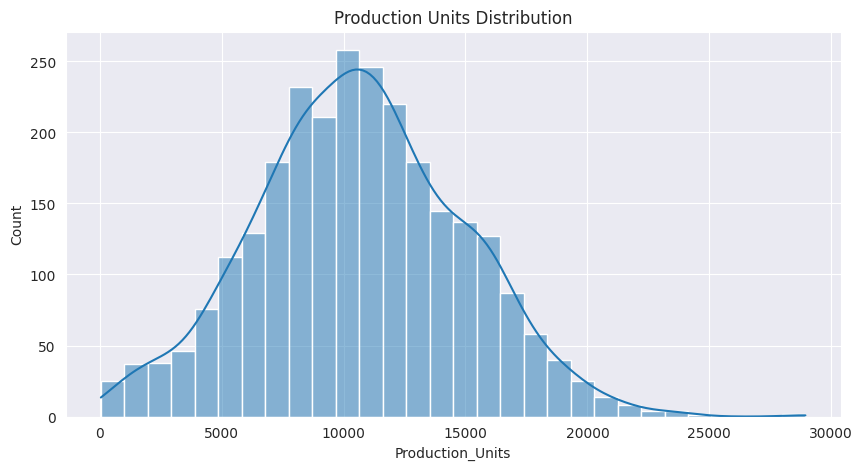

In [20]:
# Production Units Distribution

plt.figure(figsize=(10,5))

sns.histplot(
    df['Production_Units'],
    bins=30,
    kde=True
)

plt.title("Production Units Distribution")

plt.show()

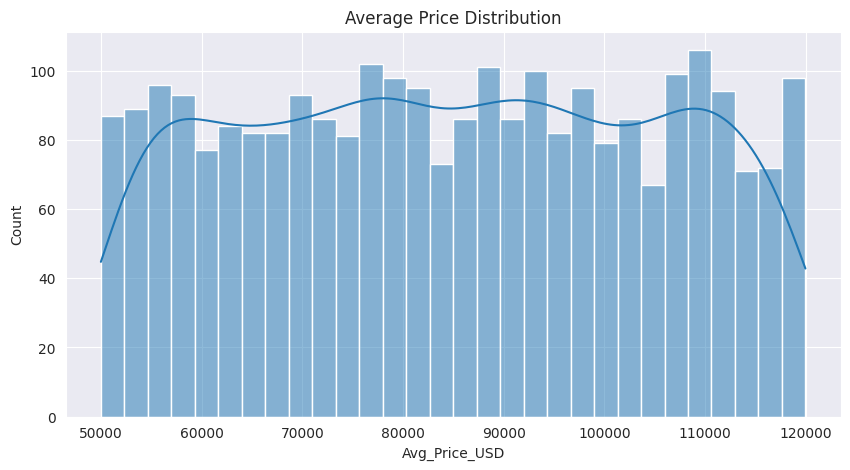

In [21]:
# Average Price Distribution
plt.figure(figsize=(10,5))

sns.histplot(
    df['Avg_Price_USD'],
    bins=30,
    kde=True
)

plt.title("Average Price Distribution")

plt.show()

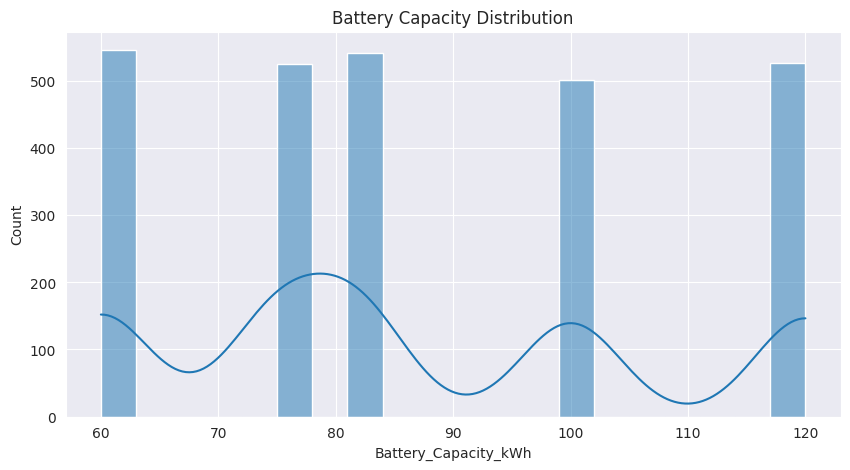

In [22]:
# Battery Capacity Distribution


plt.figure(figsize=(10,5))

sns.histplot(
    df['Battery_Capacity_kWh'],
    bins=20,
    kde=True
)

plt.title("Battery Capacity Distribution")

plt.show()

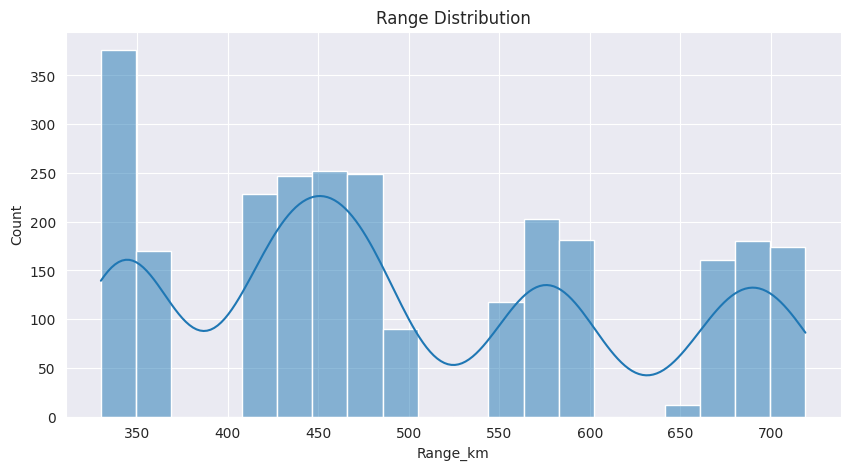

In [23]:
# Range Distribution

plt.figure(figsize=(10,5))

sns.histplot(
    df['Range_km'],
    bins=20,
    kde=True
)

plt.title("Range Distribution")

plt.show()

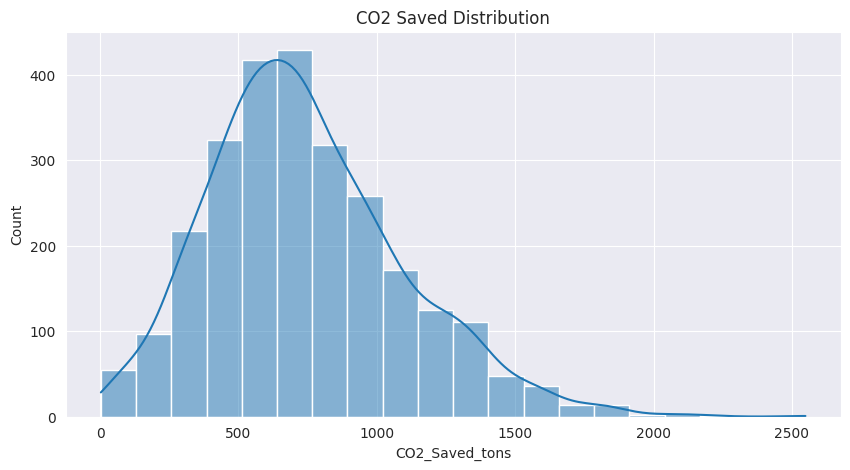

In [24]:

# CO2 Saved Distribution

plt.figure(figsize=(10,5))

sns.histplot(
    df['CO2_Saved_tons'],
    bins=20,
    kde=True
)

plt.title("CO2 Saved Distribution")

plt.show()

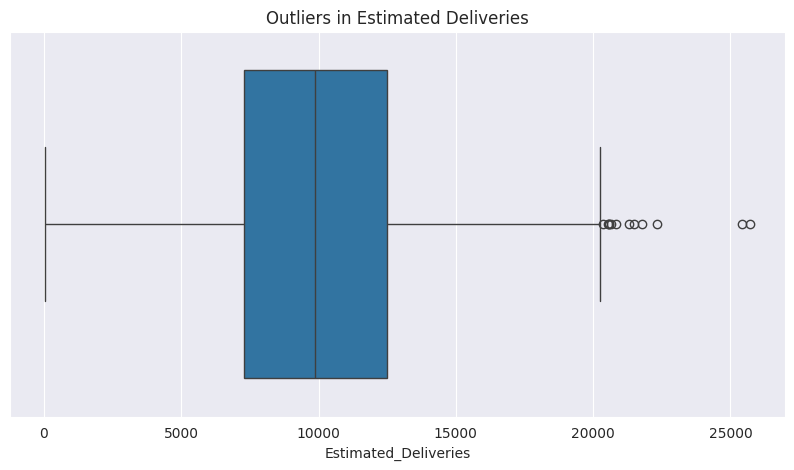

In [25]:
# 7. OUTLIER DETECTION

plt.figure(figsize=(10,5))

sns.boxplot(
    x=df['Estimated_Deliveries']
)

plt.title("Outliers in Estimated Deliveries")

plt.show()

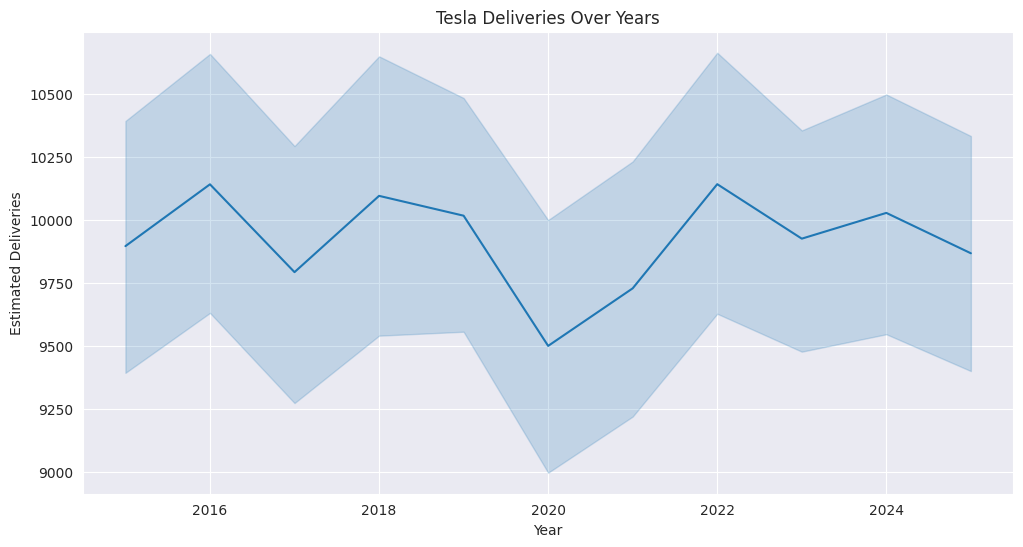

In [26]:
# Deliveries Over Years

plt.figure(figsize=(12,6))

sns.lineplot(
    x='Year',
    y='Estimated_Deliveries',
    data=df
)

plt.title("Tesla Deliveries Over Years")
plt.xlabel("Year")
plt.ylabel("Estimated Deliveries")

plt.show()

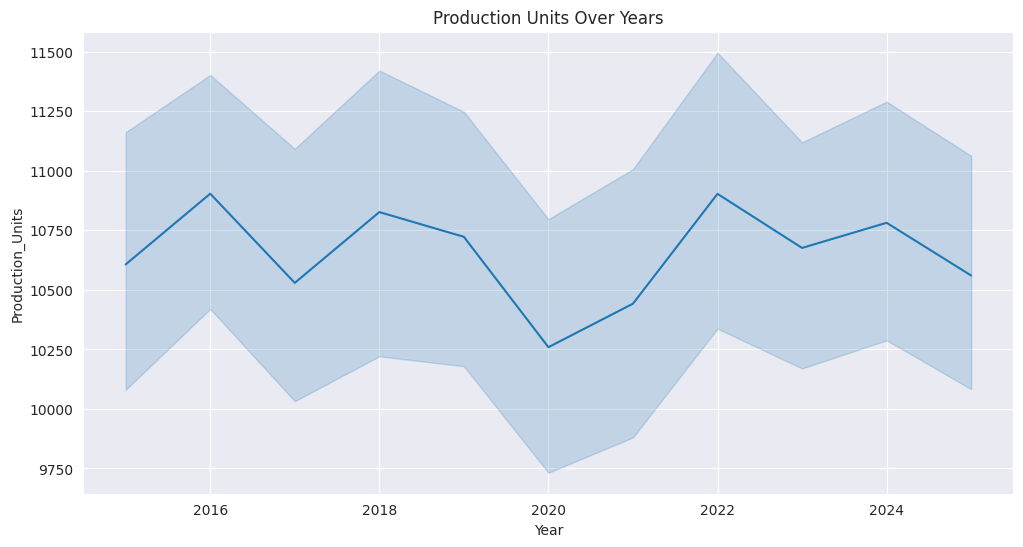

In [27]:
# Production Over Years

plt.figure(figsize=(12,6))

sns.lineplot(
    x='Year',
    y='Production_Units',
    data=df
)

plt.title("Production Units Over Years")

plt.show()

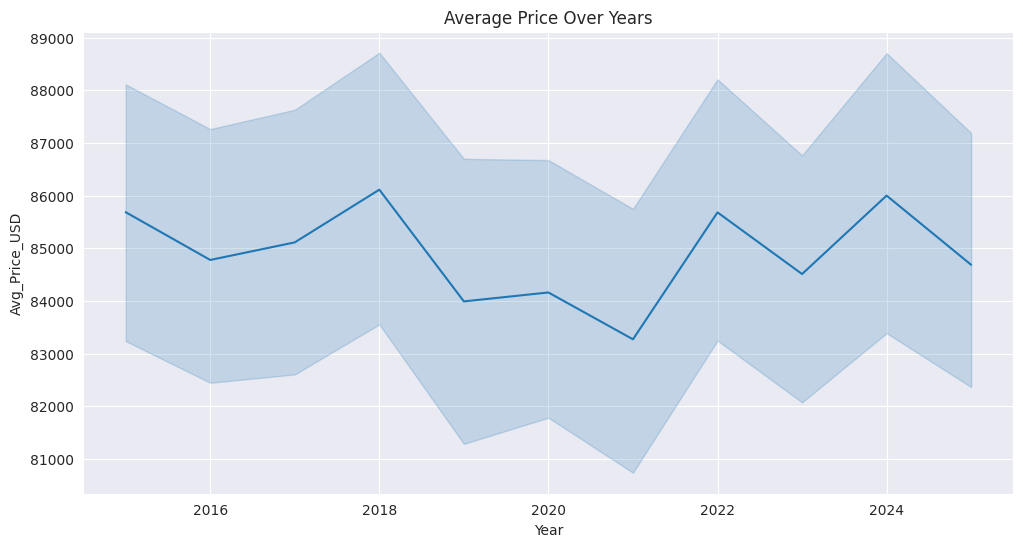

In [28]:
# Average Price Over Years

plt.figure(figsize=(12,6))

sns.lineplot(
    x='Year',
    y='Avg_Price_USD',
    data=df
)

plt.title("Average Price Over Years")

plt.show()

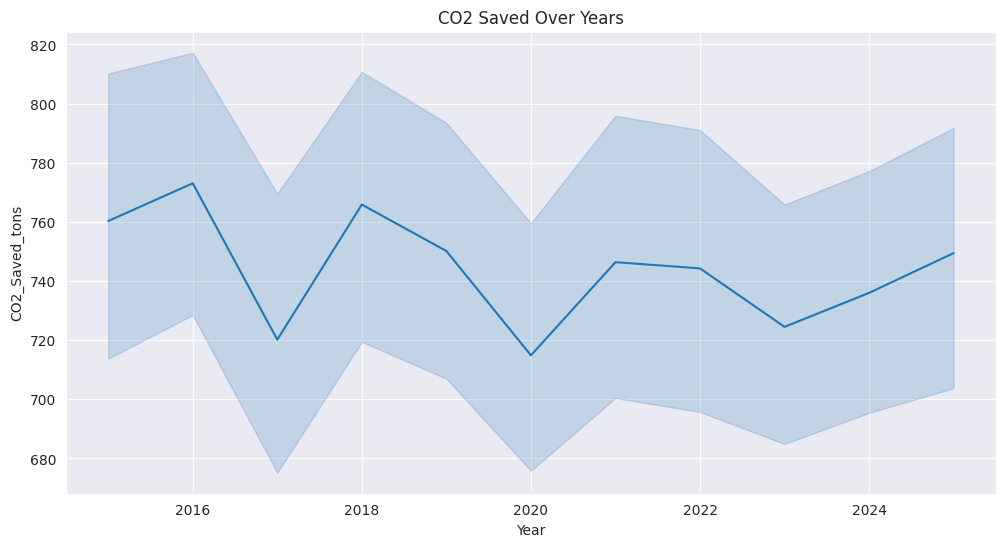

In [29]:
# CO2 Saved Over Years

plt.figure(figsize=(12,6))

sns.lineplot(
    x='Year',
    y='CO2_Saved_tons',
    data=df
)

plt.title("CO2 Saved Over Years")

plt.show()

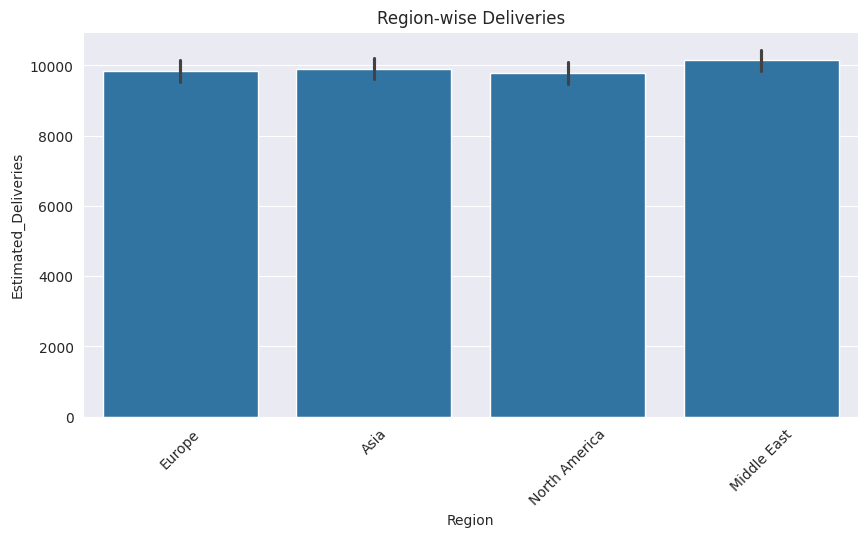

In [30]:
# Deliveries by Region
# ------------------------------------------------------------

plt.figure(figsize=(10,5))

sns.barplot(
    x='Region',
    y='Estimated_Deliveries',
    data=df
)

plt.title("Region-wise Deliveries")

plt.xticks(rotation=45)

plt.show()


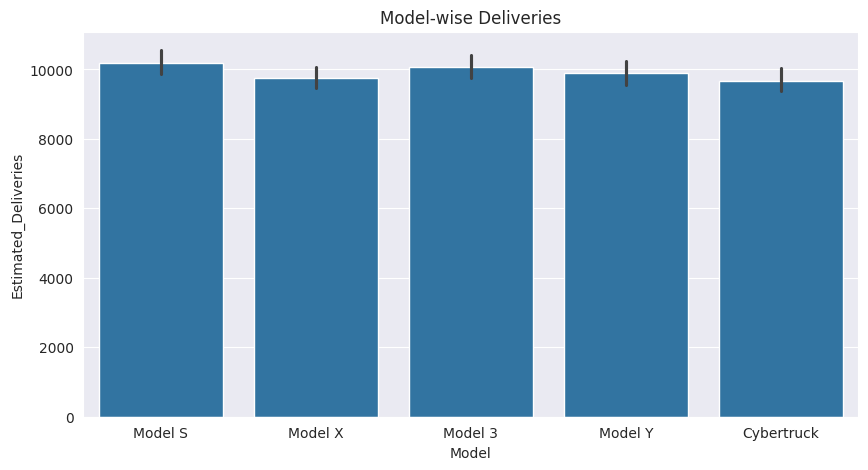

In [31]:
# Deliveries by Model
# ------------------------------------------------------------

plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='Estimated_Deliveries',
    data=df
)

plt.title("Model-wise Deliveries")

plt.show()

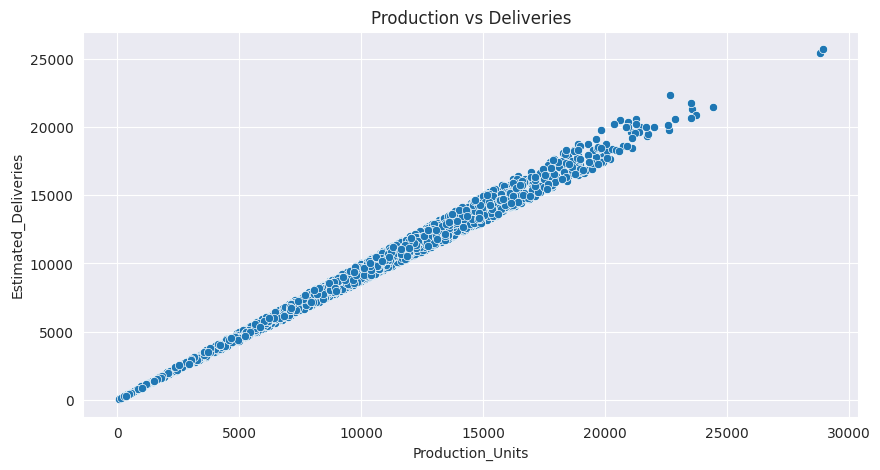

In [32]:
# Production vs Deliveries
# ------------------------------------------------------------

plt.figure(figsize=(10,5))

sns.scatterplot(
    x='Production_Units',
    y='Estimated_Deliveries',
    data=df
)

plt.title("Production vs Deliveries")

plt.show()

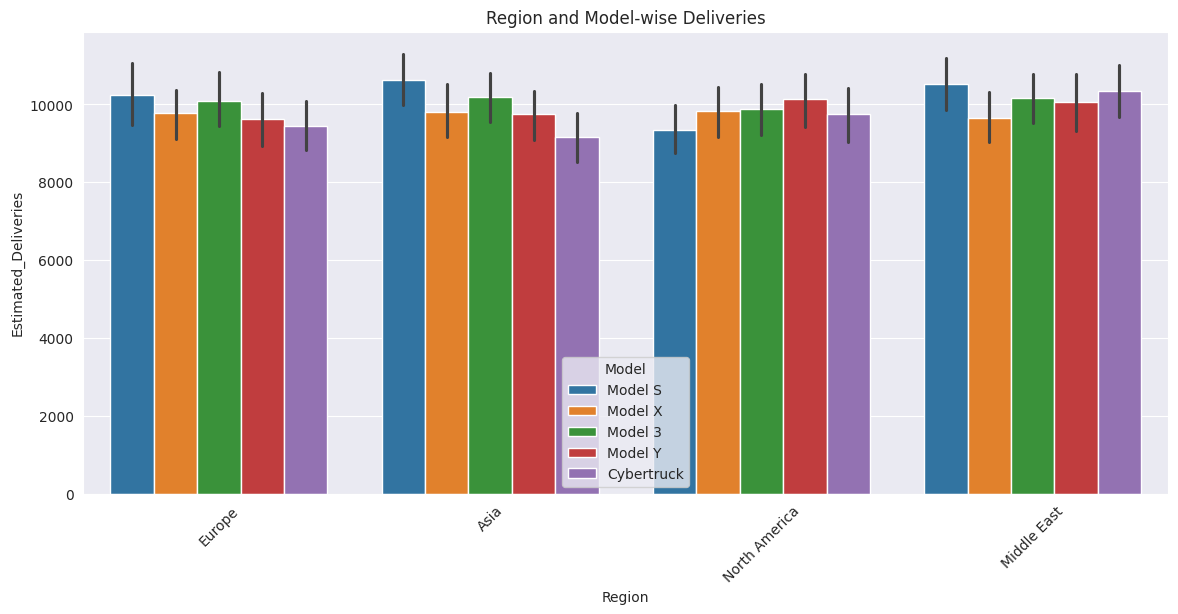

In [33]:
# 9. MULTIVARIATE ANALYSIS

plt.figure(figsize=(14,6))

sns.barplot(
    x='Region',
    y='Estimated_Deliveries',
    hue='Model',
    data=df
)

plt.title("Region and Model-wise Deliveries")

plt.xticks(rotation=45)

plt.show()

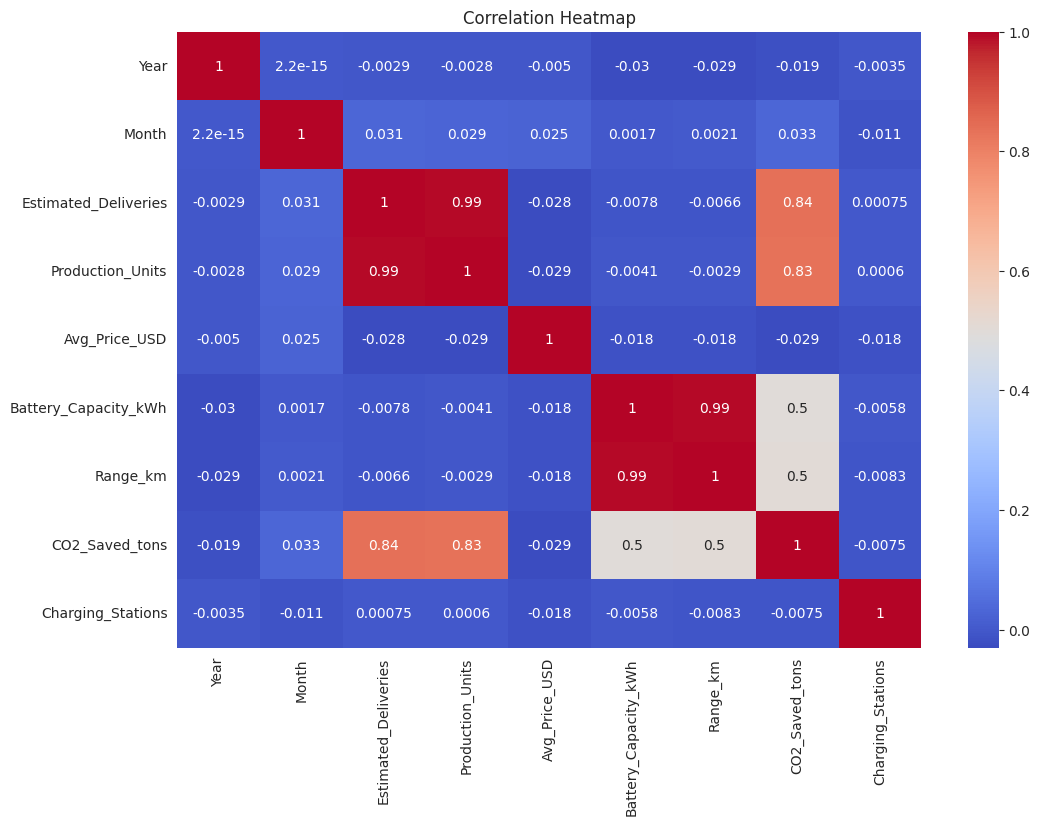

In [34]:
# 10. CORRELATION HEATMAP

plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [35]:
#FEATURE ENGINEERING

# Delivery Production Ratio
df['Delivery_Production_Ratio'] = (
    df['Estimated_Deliveries'] /
    df['Production_Units']
)


# Price Per KM
df['Price_Per_KM'] = (
    df['Avg_Price_USD'] /
    df['Range_km']
)

# Charging Density
df['Charging_Density'] = (
    df['Charging_Stations'] /
    df['Estimated_Deliveries']
)


df['Yearly_Growth'] = (
    df['Estimated_Deliveries'].pct_change()
)

df['Rolling_Mean'] = (
    df['Estimated_Deliveries']
    .rolling(window=3)
    .mean()
)

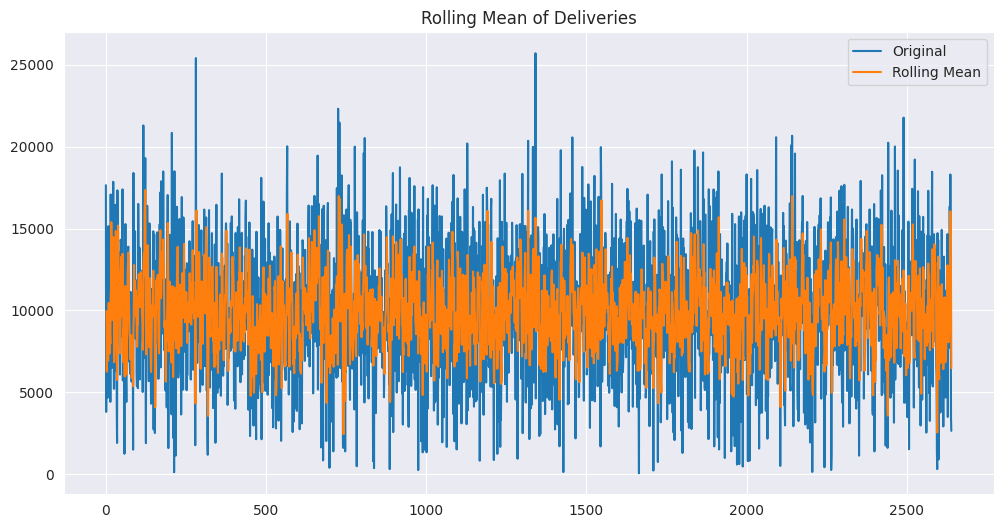

In [36]:
#ROLLING STATISTICS VISUALIZATION

plt.figure(figsize=(12,6))

plt.plot(
    df['Estimated_Deliveries'],
    label='Original'
)

plt.plot(
    df['Rolling_Mean'],
    label='Rolling Mean'
)

plt.legend()

plt.title("Rolling Mean of Deliveries")

plt.show()

In [37]:
#ENCODING CATEGORICAL VARIABLES

label_encoder = LabelEncoder()

categorical_columns = [
    'Region',
    'Model',
    'Source_Type'
]

for col in categorical_columns:

    df[col] = label_encoder.fit_transform(df[col])

In [38]:
# REMOVE NaN VALUES

df = df.dropna()

# FEATURE SELECTION

X = df.drop(columns=['Estimated_Deliveries'])

y = df['Estimated_Deliveries']

In [39]:
#FEATURE SCALING

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [40]:
#TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
#LINEAR REGRESSION

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

y_pred_linear = linear_model.predict(X_test)

In [42]:
#RIDGE REGRESSION

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_train,
    y_train
)

y_pred_ridge = ridge_model.predict(X_test)


In [43]:
#LASSO REGRESSION

lasso_model = Lasso(alpha=0.1)

lasso_model.fit(
    X_train,
    y_train
)

y_pred_lasso = lasso_model.predict(X_test)

In [44]:
#MODEL EVALUATION FUNCTION


def evaluate_model(
    y_true,
    y_pred,
    model_name
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true,
        y_pred
    )

    print("\n", model_name)

    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

In [45]:
# EVALUATE LINEAR REGRESSION
evaluate_model(
    y_test,
    y_pred_linear,
    "Linear Regression"
)

# EVALUATE RIDGE REGRESSION
evaluate_model(
    y_test,
    y_pred_ridge,
    "Ridge Regression"
)



# EVALUATE LASSO REGRESSION
evaluate_model(
    y_test,
    y_pred_lasso,
    "Lasso Regression"
)


 Linear Regression
MAE : 107.17990420511438
MSE : 24277.97700181219
RMSE: 155.8139178694002
R2 Score: 0.9983963450097927

 Ridge Regression
MAE : 106.91454439327299
MSE : 23923.502687085922
RMSE: 154.67224278158614
R2 Score: 0.998419759419637

 Lasso Regression
MAE : 106.93114832286395
MSE : 24261.86932362824
RMSE: 155.76222046320552
R2 Score: 0.998397408984707


In [46]:
# CROSS VALIDATION

cv_scores = cross_val_score(
    linear_model,
    X_scaled,
    y,
    cv=5
)

print("\nCross Validation Scores")
print(cv_scores)

print("\nAverage CV Score")
print(cv_scores.mean())



Cross Validation Scores
[0.99850127 0.99851542 0.99822841 0.99817568 0.99853792]

Average CV Score
0.9983917376790423


In [47]:
# HYPERPARAMETER TUNING

ridge_params = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=5
)

grid_search.fit(
    X_train,
    y_train
)

print("\nBest Parameters")
print(grid_search.best_params_)


Best Parameters
{'alpha': 0.01}


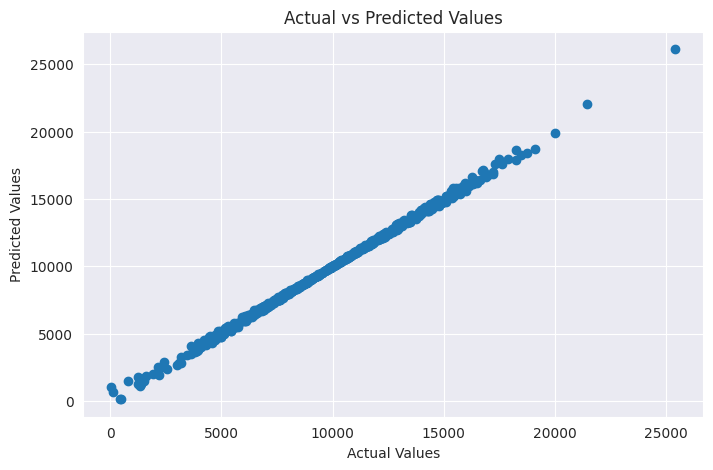

In [48]:
# ACTUAL VS PREDICTED

plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred_linear
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted Values")

plt.show()

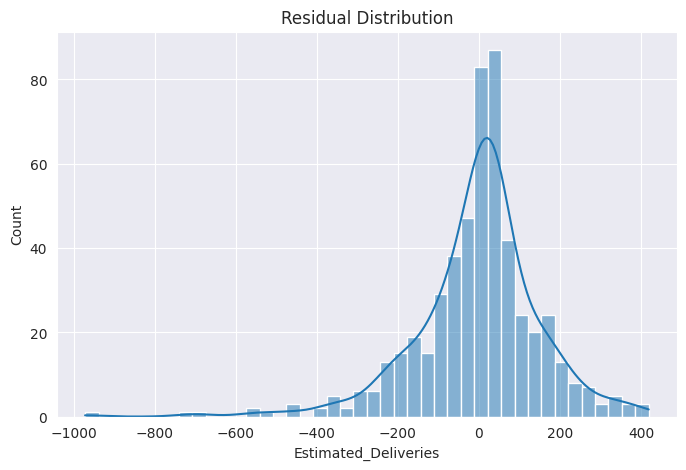

In [49]:
# RESIDUAL DISTRIBUTION

residuals = (
    y_test -
    y_pred_linear
)

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

In [50]:
# FINAL INSIGHTS

print("\nKEY INSIGHTS")

print("1. Tesla deliveries increased significantly after 2020.")
print("2. Production units strongly correlate with deliveries.")
print("3. Battery capacity positively impacts driving range.")
print("4. Charging infrastructure supports EV adoption.")
print("5. CO2 savings increased over the years.")
print("6. Ridge and Lasso help reduce overfitting.")


KEY INSIGHTS
1. Tesla deliveries increased significantly after 2020.
2. Production units strongly correlate with deliveries.
3. Battery capacity positively impacts driving range.
4. Charging infrastructure supports EV adoption.
5. CO2 savings increased over the years.
6. Ridge and Lasso help reduce overfitting.


In [51]:
# DONE